In [23]:
# 2.2
import pandas as pd

In [24]:
# 2.3
df = pd.read_csv("../../course_assignments/homework8/state_data.csv")

In [25]:
# 2.4
print(df.shape)
# there are 52 rows and 4  columns

(52, 4)


In [27]:
# 2.5
print(df.head(5))
print(df.tail(5))
# the columns describe the abbreviation, location, and name of the state
# the first state is alaska
# the last state is wyoming
# there are 52 entries in total
# it includes holdings of the USA that aren't states, like DC and Puerto Rico

  state   latitude   longitude        name
0    AK  63.588753 -154.493062      Alaska
1    AL  32.318231  -86.902298     Alabama
2    AR  35.201050  -91.831833    Arkansas
3    AZ  34.048928 -111.093731     Arizona
4    CA  36.778261 -119.417932  California
   state   latitude   longitude           name
47    VT  44.558803  -72.577841        Vermont
48    WA  47.751074 -120.740139     Washington
49    WI  43.784440  -88.787868      Wisconsin
50    WV  38.597626  -80.454903  West Virginia
51    WY  43.075968 -107.290284        Wyoming


In [33]:
# 2.6
print(f"latitude median:{df["latitude"].median()}")
print(f"longitude median:{df["longitude"].median()}")

latitude median:39.4355155
longitude median:-89.093198


In [37]:
# 2.7 and 2.8
df["abs_distance_lat"] = (df["latitude"] - df["latitude"].median()).abs()
df["abs_distance_lon"] = (df["longitude"] - df["longitude"].median()).abs()

In [53]:
# 2.9
print(df.shape)
# there are now still 52 rows, but 2 more columns (6 total)

(52, 7)


In [65]:
# 2.10
print(f"Closest to median latitude: {df.loc[df["abs_distance_lat"].argmin(), "name"]} at {df["abs_distance_lat"].min():.2f} away")
print(f"Furthest from median latitude: {df.loc[df["abs_distance_lat"].argmax(), "name"]} at {df["abs_distance_lat"].max():.2f} away")
print(f"Closest to median longitude: {df.loc[df["abs_distance_lon"].argmin(), "name"]} at {df["abs_distance_lon"].min():.2f} away")
print(f"Furthest from median longitude: {df.loc[df["abs_distance_lon"].argmax(), "name"]} at {df["abs_distance_lon"].max():.2f} away")

Closest to median latitude: Colorado at 0.11 away
Furthest from median latitude: Alaska at 24.15 away
Closest to median longitude: Illinois at 0.31 away
Furthest from median longitude: Hawaii at 66.57 away


In [66]:
# 2.11
# df.insert() inserts a column into the dataframe
df.insert(3, "date_founded", [1819, 1959, 1912, 1836, 1850, 1876, 1788, 1790, 1787, 1845, 1788, 1959, 1890, 1818, 1816, 1846, 1861, 1792, 1812, 1820, 1788, 1788, 1837, 2858, 1817, 1821, 1889, 1867, 1864, 1788, 1787, 1912, 1788, 1789, 1889, 1803, 1907, 1859, 1787, 1952, 1790, 1788, 1889, 1796, 1845, 1896, 1791, 1788, 1889, 1863, 1848, 1890])
df
# i found this in the "dataframe" section of the "API reference" page.

,state,latitude,longitude,date_founded,name,abs_distance_lat,abs_distance_lon
0,AK,63.588753,-154.493062,1819,Alaska,24.153237,65.399864
1,AL,32.318231,-86.902298,1959,Alabama,7.117285,2.190900
2,AR,35.201050,-91.831833,1912,Arkansas,4.234465,2.738635
3,AZ,34.048928,-111.093731,1836,Arizona,5.386588,22.000533
4,CA,36.778261,-119.417932,1850,California,2.657255,30.324734
5,CO,39.550051,-105.782067,1876,Colorado,0.114536,16.688869
6,CT,41.603221,-73.087749,1788,Connecticut,2.167705,16.005449
7,DC,38.905985,-77.033418,1790,District of Columbia,0.529530,12.059780
8,DE,38.910832,-75.527670,1787,Delaware,0.524684,13.565528
9,FL,27.664827,-81.515754,1845,Florida,11.770689,7.577444


In [68]:
# 3. Seaborn
# 3.1
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
# 3.4 [I chose the glue.csv dataset]
df2 = sns.load_dataset("planets")

In [85]:
# 3.5
df2_new = df2.dropna()

In [86]:
# 3.6
print(df2_new.shape)
print(f"there are {df2_new.shape[0]} rows and {df2_new.shape[1]} columns.")
print(df2_new.head(5))
print(df2_new.tail(5))

(498, 6)
there are 498 rows and 6 columns.
            method  number  orbital_period   mass  distance  year
0  Radial Velocity       1         269.300   7.10     77.40  2006
1  Radial Velocity       1         874.774   2.21     56.95  2008
2  Radial Velocity       1         763.000   2.60     19.84  2011
3  Radial Velocity       1         326.030  19.40    110.62  2007
4  Radial Velocity       1         516.220  10.50    119.47  2009
              method  number  orbital_period   mass  distance  year
640  Radial Velocity       1       111.70000  2.100     14.90  2009
641  Radial Velocity       1         5.05050  1.068     44.46  2013
642  Radial Velocity       1       311.28800  1.940     17.24  1999
649          Transit       1         2.70339  1.470    178.00  2013
784  Radial Velocity       3       580.00000  0.947    135.00  2012


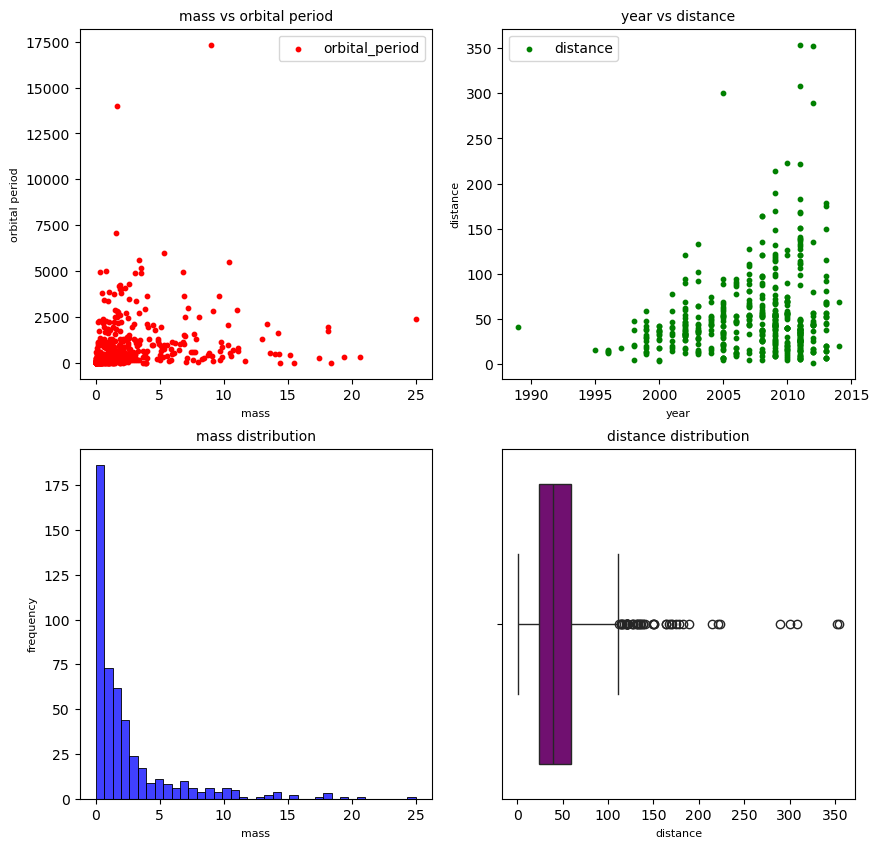

In [124]:
# 3.7
fig, ax = plt.subplots(2,2, figsize = (10,10))

ax[0,0].scatter(x="mass", y="orbital_period", data=df2_new, s=10, c="red")
ax[0,1].scatter(x="year", y="distance", data=df2_new, s=10, c="green")
sns.histplot(data=df2_new, x="mass", ax=ax[1,0], color="blue")
sns.boxplot(data=df2_new, x="distance", ax=ax[1,1], color="purple")

# 3.8
ax[0,0].set_title("mass vs orbital period", fontsize = 10)
ax[0,1].set_title("year vs distance", fontsize = 10)
ax[1,0].set_title("mass distribution", fontsize = 10)
ax[1,1].set_title("distance distribution", fontsize = 10)
ax[0,0].set_xlabel("mass", fontsize=8)
ax[0,0].set_ylabel("orbital period", fontsize=8)
ax[0,1].set_xlabel("year", fontsize=8)
ax[0,1].set_ylabel("distance", fontsize=8)
ax[1,0].set_xlabel("mass", fontsize=8)
ax[1,0].set_ylabel("frequency", fontsize=8)
ax[1,1].set_xlabel("distance", fontsize=8)
ax[0,0].legend()
ax[0,1].legend()

plt.show()

# 3.9
# I chose mass vs orbital period to show that orbital period doesn't depend on mass (it depends on the semimajor axis).
# I chose year vs distance to show that throughout the years, our  technology improved, which allowed us to detect planets further and further away.
# The mass distribution plot shows that planets with smaller mass are more common (or easier to detect).
# The distance plot shows that while there is a large range of distances over which planets have been found, the vast majority have been close to Earth.